In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

## Scaling

In [3]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')

df

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-FGC_CU,...,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,Physical-BMI,BIA-BIA_TBW,BIA-BIA_FFM,BIA-BIA_DEE,BIA-BIA_FMI
0,5.0,0.0,51.00,46.0000,50.8,26.000,68.76,80.63,114.00,0.0,...,2.0004,2.59564,63.64,3.0,448.00,16.878972,32.690880,41.586250,1282.184750,1.555190
1,9.0,0.0,60.92,48.0000,46.0,22.000,75.00,70.00,122.00,3.0,...,2.0100,2.34000,64.00,0.0,426.15,14.036968,27.055130,42.029190,1287.902000,0.557387
2,10.0,1.0,71.00,56.5000,75.6,26.020,65.00,94.00,117.00,20.0,...,2.0022,2.17000,54.00,2.0,453.00,16.650330,44.692746,60.919120,NaN,2.693124
3,9.0,0.0,71.00,56.0000,81.6,26.000,60.00,97.00,117.00,18.0,...,2.0098,2.45100,45.00,0.0,577.00,18.294143,45.996600,62.775710,1753.716500,3.443744
4,18.0,1.0,65.00,55.3122,77.0,26.000,68.00,81.80,114.54,9.0,...,1.0400,2.45820,74.94,1.0,436.24,17.694847,44.783800,60.931266,1724.581670,2.862071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,64.35,46.0700,49.0,22.250,58.50,82.50,105.18,4.5,...,2.0000,3.00000,55.00,0.0,510.00,16.231461,29.416894,39.780289,1174.811919,0.515183
8456,10.0,1.0,69.50,56.1300,47.8,28.500,66.00,80.50,107.50,7.5,...,2.0000,3.00000,55.41,0.0,451.50,10.666840,36.545980,51.538156,1595.587896,0.816143
8457,10.0,1.0,70.00,49.5600,47.2,26.144,63.50,83.50,119.50,14.5,...,2.1024,2.00000,67.63,2.0,528.00,13.510685,44.874578,54.796427,1784.318608,-20.544617
8458,15.0,1.0,55.50,63.7900,99.5,31.100,70.22,87.50,108.00,10.0,...,2.0000,2.00000,54.46,1.0,478.00,17.191581,60.685667,81.542008,1897.092239,4.593359


In [ ]:
# separate features and target variable in order to not bias future models
#X = df.drop(columns=['sii'])
#y = np.array(df['sii'])

X = df.drop(columns=['BIA-BIA_DEE']) # just while it is not fixed


In [29]:
X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-FGC_CU,...,BIA-BIA_SMM,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,Physical-BMI,BIA-BIA_TBW,BIA-BIA_FFM,BIA-BIA_FMI
0,5.0,0.0,51.00,46.0000,50.8,26.000,68.76,80.63,114.00,0.0,...,19.541300,2.0004,2.59564,63.64,3.0,448.00,16.878972,32.690880,41.586250,1.555190
1,9.0,0.0,60.92,48.0000,46.0,22.000,75.00,70.00,122.00,3.0,...,15.410700,2.0100,2.34000,64.00,0.0,426.15,14.036968,27.055130,42.029190,0.557387
2,10.0,1.0,71.00,56.5000,75.6,26.020,65.00,94.00,117.00,20.0,...,27.383308,2.0022,2.17000,54.00,2.0,453.00,16.650330,44.692746,60.919120,2.693124
3,9.0,0.0,71.00,56.0000,81.6,26.000,60.00,97.00,117.00,18.0,...,26.479800,2.0098,2.45100,45.00,0.0,577.00,18.294143,45.996600,62.775710,3.443744
4,18.0,1.0,65.00,55.3122,77.0,26.000,68.00,81.80,114.54,9.0,...,27.301903,1.0400,2.45820,74.94,1.0,436.24,17.694847,44.783800,60.931266,2.862071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,64.35,46.0700,49.0,22.250,58.50,82.50,105.18,4.5,...,19.993886,2.0000,3.00000,55.00,0.0,510.00,16.231461,29.416894,39.780289,0.515183
8456,10.0,1.0,69.50,56.1300,47.8,28.500,66.00,80.50,107.50,7.5,...,22.983200,2.0000,3.00000,55.41,0.0,451.50,10.666840,36.545980,51.538156,0.816143
8457,10.0,1.0,70.00,49.5600,47.2,26.144,63.50,83.50,119.50,14.5,...,31.594712,2.1024,2.00000,67.63,2.0,528.00,13.510685,44.874578,54.796427,-20.544617
8458,15.0,1.0,55.50,63.7900,99.5,31.100,70.22,87.50,108.00,10.0,...,46.467581,2.0000,2.00000,54.46,1.0,478.00,17.191581,60.685667,81.542008,4.593359


In [5]:
from sklearn.preprocessing import StandardScaler


In [30]:
scl = StandardScaler()
X = scl.fit_transform(X)

## Box Plots

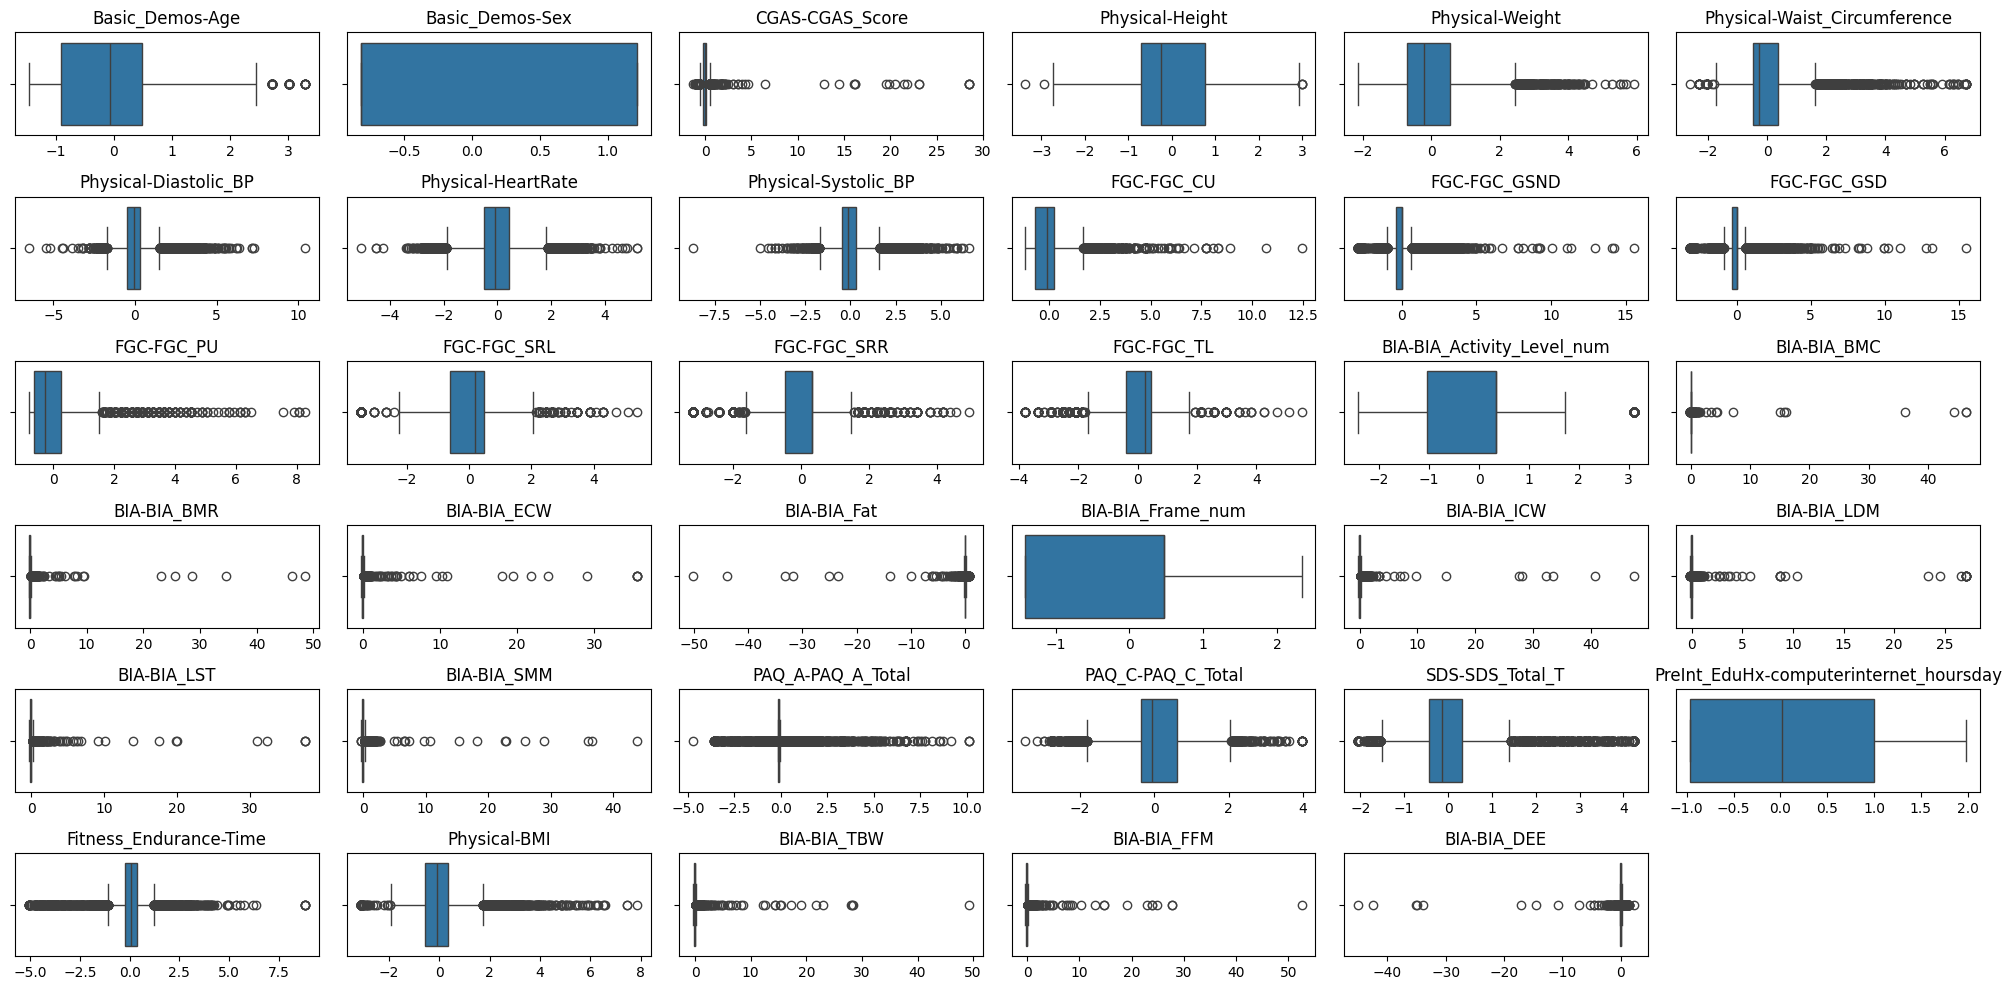

In [31]:
# Create box plots for each feature, using the names of the columns in the original DataFrame
plt.figure(figsize=(20, 10))
for i in range(X.shape[1]):
    plt.subplot(6, 6, i + 1)
    sns.boxplot(x=X[:, i])
    plt.title(df.columns[i])
plt.tight_layout()
plt.show()

Age and Height have very few outliers
Weight, WaistCircumference, etc have quite a lot
Most of the BIA variables have extremely skewed distributions

In [17]:
# Count points outside the whiskers for each feature
outliers_count = {}
for i in range(X.shape[1]):
    Q1 = np.percentile(X[:, i], 25)
    Q3 = np.percentile(X[:, i], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count[df.columns[i]] = np.sum((X[:, i] < lower_bound) | (X[:, i] > upper_bound))
outliers_count

{'Basic_Demos-Age': np.int64(84),
 'Basic_Demos-Sex': np.int64(0),
 'CGAS-CGAS_Score': np.int64(562),
 'Physical-Height': np.int64(5),
 'Physical-Weight': np.int64(220),
 'Physical-Waist_Circumference': np.int64(539),
 'Physical-Diastolic_BP': np.int64(704),
 'Physical-HeartRate': np.int64(612),
 'Physical-Systolic_BP': np.int64(721),
 'FGC-FGC_CU': np.int64(486),
 'FGC-FGC_GSND': np.int64(1717),
 'FGC-FGC_GSD': np.int64(2086),
 'FGC-FGC_PU': np.int64(576),
 'FGC-FGC_SRL': np.int64(328),
 'FGC-FGC_SRR': np.int64(763),
 'FGC-FGC_TL': np.int64(624),
 'BIA-BIA_Activity_Level_num': np.int64(119),
 'BIA-BIA_BMC': np.int64(552),
 'BIA-BIA_BMR': np.int64(460),
 'BIA-BIA_ECW': np.int64(453),
 'BIA-BIA_Fat': np.int64(637),
 'BIA-BIA_Frame_num': np.int64(0),
 'BIA-BIA_ICW': np.int64(830),
 'BIA-BIA_LDM': np.int64(612),
 'BIA-BIA_LST': np.int64(667),
 'BIA-BIA_SMM': np.int64(561),
 'PAQ_A-PAQ_A_Total': np.int64(1880),
 'PAQ_C-PAQ_C_Total': np.int64(803),
 'SDS-SDS_Total_T': np.int64(986),
 'PreIn

How much do we want to micromanage? 
Because some of the results don't agree with what we looked for and wrote down on the excel

Age: in theory all are in the expected range (excel) \\
Sex: all fine \\
CGAS-CGAS_Score: a lot of outliers, but \\
Height: fine (excel) \\

For example:

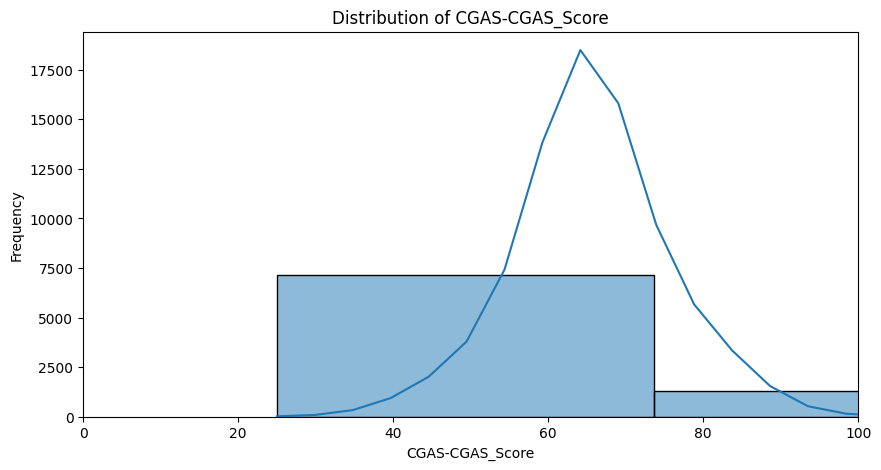

In [ ]:
# Show the distribution of CGAS-CGAS_Score  with a histogram using the original DataFrame and the column name
plt.figure(figsize=(10, 5))
sns.histplot(df['CGAS-CGAS_Score'], bins=20, kde=True)
plt.title('Distribution of CGAS-CGAS_Score')
 #plt.xlim(0,100)
plt.xlabel('CGAS-CGAS_Score')
plt.ylabel('Frequency')
plt.show()  

In [ ]:
# Function for if we want to change k
def is_outlier(x, k=1.5):
    q1 = np.quantile(x, 0.25)
    q3 = np.quantile(x, 0.75)
    iqr = q3 - q1
    outliers = list()
    for v in x:
        if v < q1 - k * iqr or v > q3 + k * iqr:
            outliers.append(True)
        else:
            outliers.append(False)
    return np.array(outliers)

In [ ]:
# for example let's calculate outliers with k=2
outliers_count_k2 = {}
for i in range(X.shape[1]):
    outliers = is_outlier(X[:,i], k=2)
    outliers_count_k2[df.columns[i]] = np.sum(outliers)
outliers_count_k2

{'Basic_Demos-Age': np.int64(0),
 'Basic_Demos-Sex': np.int64(0),
 'CGAS-CGAS_Score': np.int64(214),
 'Physical-Height': np.int64(0),
 'Physical-Weight': np.int64(115),
 'Physical-Waist_Circumference': np.int64(344),
 'Physical-Diastolic_BP': np.int64(429),
 'Physical-HeartRate': np.int64(277),
 'Physical-Systolic_BP': np.int64(437),
 'FGC-FGC_CU': np.int64(298),
 'FGC-FGC_GSND': np.int64(1124),
 'FGC-FGC_GSD': np.int64(1506),
 'FGC-FGC_PU': np.int64(422),
 'FGC-FGC_SRL': np.int64(216),
 'FGC-FGC_SRR': np.int64(443),
 'FGC-FGC_TL': np.int64(375),
 'BIA-BIA_Activity_Level_num': np.int64(0),
 'BIA-BIA_BMC': np.int64(348),
 'BIA-BIA_BMR': np.int64(288),
 'BIA-BIA_ECW': np.int64(232),
 'BIA-BIA_Fat': np.int64(438),
 'BIA-BIA_Frame_num': np.int64(0),
 'BIA-BIA_ICW': np.int64(607),
 'BIA-BIA_LDM': np.int64(334),
 'BIA-BIA_LST': np.int64(431),
 'BIA-BIA_SMM': np.int64(369),
 'PAQ_A-PAQ_A_Total': np.int64(1755),
 'PAQ_C-PAQ_C_Total': np.int64(352),
 'SDS-SDS_Total_T': np.int64(530),
 'PreInt_E

## HBOS

In [ ]:
# !pip install pyod

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 3.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 3.6 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pyod]1/3 [numba]


In [25]:
from pyod.models.hbos import HBOS

In [32]:
outd = HBOS()

outd.fit(X)

,n_bins,10
,alpha,0.1
,tol,0.5
,contamination,0.1


In [33]:
outd.decision_scores_

array([41.04073403, 44.57555928, 43.38089961, ..., 45.47102362,
       41.49260999, 38.01916648], shape=(8460,))

In [34]:
outliers = outd.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([7614,  846]))

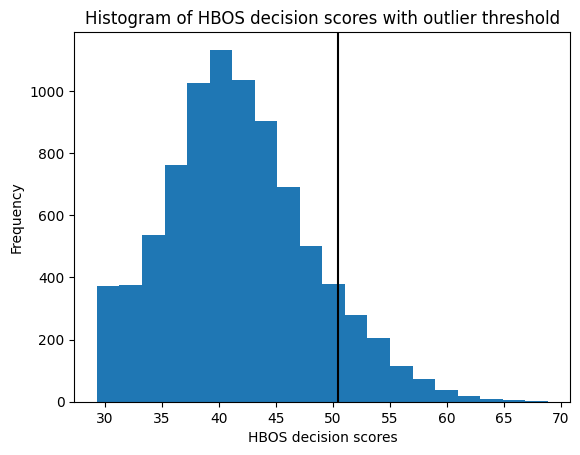

In [ ]:
plt.hist(outd.decision_scores_, bins=20)
plt.axvline(np.min(outd.decision_scores_[np.where(outliers==1)]), c='k')
plt.xlabel('HBOS decision scores')
plt.ylabel('Frequency')
plt.title('Histogram of HBOS decision scores with outlier threshold')
plt.show()

In [ ]:
outd.decision_function(X)
# same as decision scores
# why do we want it?

array([41.04073403, 44.57555928, 43.38089961, ..., 45.47102362,
       41.49260999, 38.01916648], shape=(8460,))